In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/crop-diseases-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.00G/2.00G [00:18<00:00, 115MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1):
['Data']


In [ ]:
import os

# Update path to match 'Data' directory found in the crop diseases dataset
data_path = os.path.join(path, 'Data')

# List subdirectories in Data (usually class labels)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['train.csv', 'label_num_to_disease_map.json', 'train_images']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1/Data) ---
Found 17938 images. Displaying 6 samples:


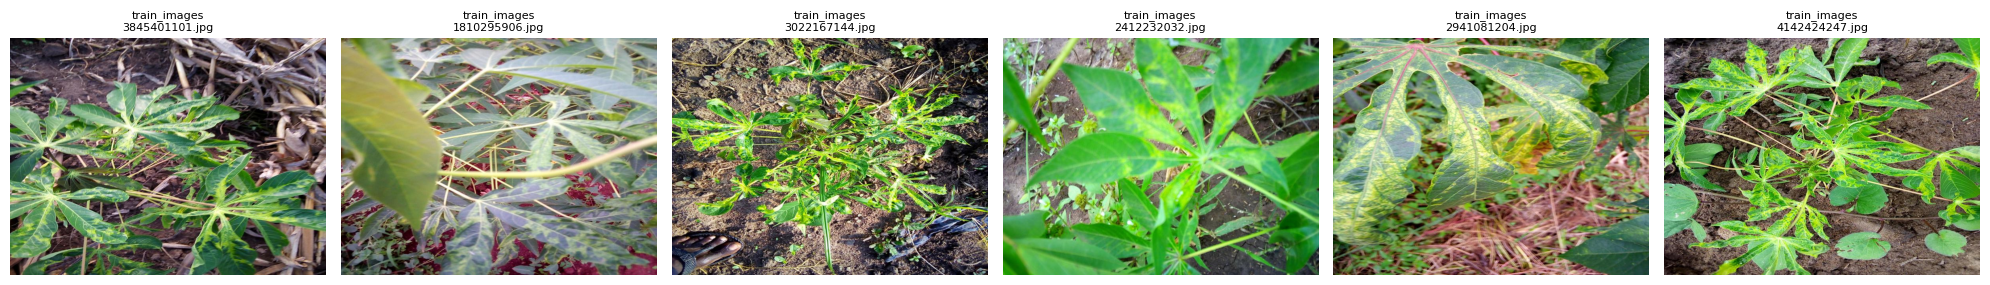

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct Data path
data_path = os.path.join(path, 'Data')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths to the CSV file and the image directory
csv_path = os.path.join(data_path, 'train.csv')
image_dir = os.path.join(data_path, 'train_images')

# Read data from CSV
df = pd.read_csv(csv_path)

# Split the dataset into 80% train and 20% test
# stratify=df['label'] ensures the proportion of crop disease classes is maintained in both sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Total samples in 'train_images': {len(df)}")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of test samples: {len(test_df)}")

# Display the first few rows of the training set for verification
display(train_df.head())

Total samples in 'train_images': 21397
Number of training samples: 17117
Number of test samples: 4280


,image_id,label
1715,1300823152.jpg,4
11830,3116613979.jpg,3
8621,2530012971.jpg,3
3849,1686186154.jpg,3
12924,3312736716.jpg,1


In [ ]:
import tensorflow as tf

# Check if GPU is available
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Colab settings (Runtime -> Change runtime type).')
else:
    print(f'Found GPU at: {device_name}')

# Basic memory growth config to avoid allocation errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Found GPU at: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

# Data preparation with ImageDataGenerator
# Note: Convert label to string as flow_from_dataframe requires categorical labels to be strings
train_df['label'] = train_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build ResNet50 Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers for initial training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='categorical_loss' if 'categorical_loss' in dir() else 'categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Found 14342 validated image filenames belonging to 5 classes.
Found 3596 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 2775 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 684 invalid image filename(s) in x_col="image_id". These filename(s) will be ignored.
  warnings.warn(


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,639,365 (93.99 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Training the model (Running for 5 epochs as an example)
epochs = 10
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 115s 224ms/step - accuracy: 0.6015 - loss: 1.2261 - val_accuracy: 0.6121 - val_loss: 1.1496
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 84s 186ms/step - accuracy: 0.6156 - loss: 1.1538 - val_accuracy: 0.6121 - val_loss: 1.1392
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 186ms/step - accuracy: 0.6160 - loss: 1.1448 - val_accuracy: 0.6121 - val_loss: 1.1327
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.6162 - loss: 1.1349 - val_accuracy: 0.6123 - val_loss: 1.1304
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 184ms/step - accuracy: 0.6171 - loss: 1.1306 - val_accuracy: 0.6160 - val_loss: 1.1222
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 84s 186ms/step - accuracy: 0.6174 - loss: 1.1229 - val_accuracy: 0.6129 - val_loss: 1.1292
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 85s 189ms/step - accuracy: 0.6192 - loss: 1.1149 - val_accuracy: 0.6207 - val_loss: 1.1195
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 85s 188ms/step - accuracy: 0.6198 - loss: 

113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - accuracy: 0.6196 - loss: 1.1013
Final Validation Loss: 1.1013
Final Validation Accuracy: 0.6196


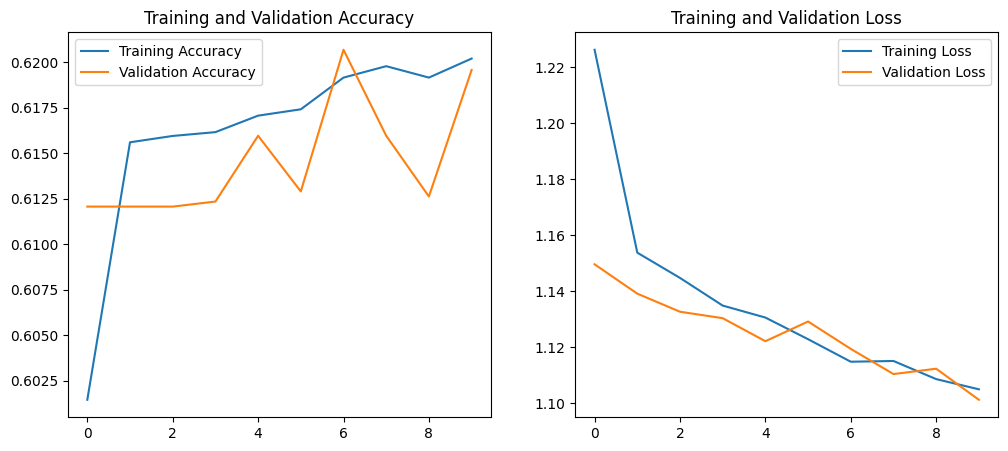

In [ ]:
import matplotlib.pyplot as plt

# Summarize results
loss, accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

# Plot training & validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()